# Phase 5 — Cross-Industry Analysis

This phase loads the outputs from Phases 3 and 4 — features and model predictions — and synthesises them into findings about greenwashing patterns across brands and industries.

### What this phase answers
- Which brands have the highest greenwash-risk scores, and does that match their external reputation?
- Is supply-chain language systematically vaguer than own-operations language?
- Which brands rely most on red-flag proprietary terms instead of recognised certifications?
- How do fashion and clean beauty differ in their sustainability language patterns?

### Pipeline overview
**`knn_predictions.parquet` + `tfidf_predictions.parquet` + `features.parquet` → merged corpus → brand/industry analysis → poster figures**

### Sections
1. Brand-level risk scores (proportions, not raw counts)
2. Own-operations vs supply-chain breakdown
3. Red-flag term rates by brand
4. Nearest-neighbour qualitative examples (top 5 per brand)
5. Cross-industry feature comparison (fashion vs clean beauty)
6. t-SNE embedding visualisation (poster figure)
7. Poster example passages

In [2]:
import json
from pathlib import Path
from textwrap import fill

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Configuration & Data Loading

Loads four files produced by earlier phases and merges them into a single analysis dataframe on `passage_id`:

| Source file | Produced by | Contents |
|---|---|---|
| `knn_predictions.parquet` | Phase 4 | kNN greenwash probability + nearest-neighbour indices for every corpus passage |
| `tfidf_predictions.parquet` | Phase 4 | TF-IDF + LR greenwash probability for every corpus passage |
| `climatebert_predictions.parquet` | Phase 4 | ClimateBERT commitment label (vague/specific) for every corpus passage |
| `features.parquet` | Phase 3 | Handcrafted features: vague language score, red-flag terms, scope, readability, etc. |

The merged `df` has one row per corpus passage with all model scores and features together — the main object used throughout this notebook.

In [3]:
ROOT     = Path('..').resolve()
RESULTS  = ROOT / 'results'
FEAT_DIR = ROOT / 'data' / 'features'
RESULTS.mkdir(parents=True, exist_ok=True)

# Load all predictions and features
knn_df   = pd.read_parquet(RESULTS / 'knn_predictions.parquet')
tfidf_df = pd.read_parquet(RESULTS / 'tfidf_predictions.parquet')
cb_df    = pd.read_parquet(RESULTS / 'climatebert_predictions.parquet')
feat_df  = pd.read_parquet(FEAT_DIR / 'features.parquet')

# Load corpus texts for qualitative display
with open(ROOT / 'data' / 'extracted' / 'passages.jsonl') as f:
    corpus = [json.loads(l) for l in f]
corpus_df = pd.DataFrame(corpus)

# Load labeled training set for nearest-neighbor display
with open(ROOT / 'data' / 'labeled' / 'labeled_passages.jsonl') as f:
    labeled = [json.loads(l) for l in f]

# Merge everything on passage_id
df = knn_df.merge(feat_df, on=['passage_id', 'brand', 'industry', 'role']) \
           .merge(tfidf_df[['passage_id', 'tfidf_pred', 'tfidf_prob']], on='passage_id') \
           .merge(cb_df[['passage_id', 'cb_label', 'cb_score']], on='passage_id')

print(f"Merged dataframe: {len(df):,} rows × {len(df.columns)} columns")
df.head(3)

Merged dataframe: 4,485 rows × 20 columns


,passage_id,brand,industry,role,knn_pred,knn_prob,nn_indices,nn_distances,vague_language_score,redflag_standard,has_specific_numbers,scope,readability_grade,unregulated_beauty_claim,text_length_chars,has_table,tfidf_pred,tfidf_prob,cb_label,cb_score
0,0,H&M,fashion,greenwashing,0,0.2857,"[9, 20, 48, 91, 35, 36, 0]","[0.424940824508667, 0.4505515694618225, 0.4977...",0.000000,0,1,supply_chain,25.736258,0,1617,True,0,0.3667,yes,0.7920
1,1,H&M,fashion,greenwashing,1,0.5714,"[0, 85, 3, 91, 48, 36, 38]","[0.45223742723464966, 0.4910358786582947, 0.49...",0.007692,0,0,unclear,16.608434,0,840,True,0,0.4593,yes,0.9458
2,2,H&M,fashion,greenwashing,0,0.2857,"[7, 41, 48, 30, 51, 88, 61]","[0.37490779161453247, 0.41586834192276, 0.4290...",0.000000,1,1,mixed,14.812857,0,1332,True,0,0.4247,yes,0.9750


## Section 1 — Brand-level risk scores

Aggregates kNN and TF-IDF greenwash probability scores to the brand level.

**Why proportions, not counts?** Reports vary widely in length — Puma has 758 passages, Eileen Fisher has only 26. Using raw counts would make longer reports look worse by default. Mean probability controls for this: a brand with 10 flagged passages out of 26 is riskier than one with 50 flagged out of 758.

**Positive controls** (Patagonia, Eileen Fisher, Reformation, L'Occitane, Lush) are B Corp certified or have substantive third-party verification. If they rank lower than fast-fashion brands, that's external validity for the model — it's picking up on real signal, not just report length or writing style.

**Output:** `results/brand_risk_scores.csv` — used in Section 2 and by `06_evaluation.ipynb` for extrinsic validation.

        brand     industry             role  passage_count  mean_knn_prob  mean_tfidf_prob  pct_knn_flagged
  Reformation      fashion        ambiguous            171         0.5397           0.4664           0.6842
      L'Oreal clean_beauty     greenwashing             23         0.5342           0.5121           0.4783
Eileen Fisher      fashion positive_control             26         0.5330           0.4570           0.5385
        Shein      fashion     greenwashing            307         0.5198           0.4873           0.5896
     Everlane      fashion        ambiguous            198         0.5195           0.4832           0.5505
    Patagonia      fashion positive_control            448         0.5061           0.4423           0.5290
    Lululemon      fashion     greenwashing            235         0.4705           0.4561           0.4468
 Ralph Lauren      fashion     greenwashing            172         0.4435           0.4607           0.3837
   L'Occitane clean_beauty p

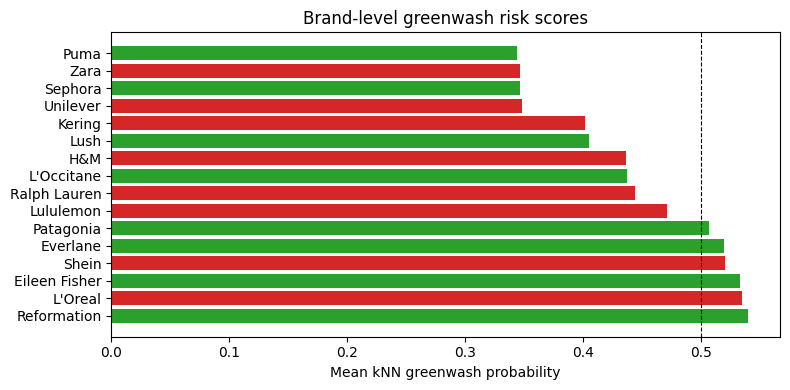

In [4]:
brand_scores = df.groupby(['brand', 'industry', 'role']).agg(
    passage_count   = ('passage_id', 'count'),
    mean_knn_prob   = ('knn_prob', 'mean'),
    mean_tfidf_prob = ('tfidf_prob', 'mean'),
    pct_knn_flagged = ('knn_pred', 'mean'),   # proportion predicted greenwash
).round(4).reset_index()
brand_scores.sort_values('mean_knn_prob', ascending=False, inplace=True)

print(brand_scores.to_string(index=False))

# Sanity check: positive controls (Patagonia, Lush) should rank lowest
controls = brand_scores[brand_scores['role'] == 'positive_control']['brand'].tolist()
print(f"\nPositive controls: {controls}")

brand_scores.to_csv(RESULTS / 'brand_risk_scores.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d62728' if r == 'greenwashing' else '#2ca02c'
          for r in brand_scores['role']]
ax.barh(brand_scores['brand'], brand_scores['mean_knn_prob'], color=colors)
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8)
ax.set(xlabel='Mean kNN greenwash probability', title='Brand-level greenwash risk scores')
plt.tight_layout()
plt.show()

## Section 2 — Own-operations vs supply-chain breakdown

Tests a specific hypothesis from greenwashing literature: brands tend to make credible claims about their own operations (energy use, office waste, direct emissions) while making vague, unverifiable claims about their supply chains (materials sourcing, supplier labour, Scope 3 emissions).

**How scope is assigned:** The `scope` feature in `features.parquet` classifies each passage as `own_ops`, `supply_chain`, or `mixed`/`unclear` based on keyword patterns from Phase 3.

**What to look for:**
- `supply_chain` mean kNN prob > `own_ops` mean kNN prob within the same brand = hypothesis supported
- Brands where this gap is largest are most likely to be engaging in selective disclosure

**Output:** Appends `own_ops_prob` and `supply_chain_prob` columns to `brand_risk_scores.csv`.

               own_ops  supply_chain
brand                               
Eileen Fisher      NaN        0.6104
Everlane        0.4429        0.5318
H&M             0.3793        0.5028
Kering             NaN        0.4219
L'Occitane      0.4286        0.4850
L'Oreal            NaN        0.6786
Lululemon       0.4286        0.5164
Lush               NaN        0.4348
Patagonia       0.3214        0.5744
Puma            0.3214        0.3691
Ralph Lauren    0.2857        0.5023
Reformation     0.6964        0.5499
Sephora         0.3846        0.3320
Shein           0.5555        0.5571
Unilever        0.2532        0.4509
Zara            0.4048        0.4519

Supply-chain > own-ops in 10/12 brands


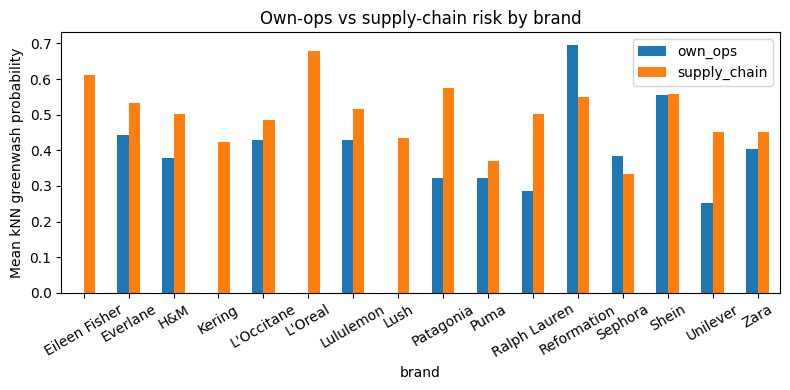

Updated → /Users/mandy.sun/green-claims-nlp/results/brand_risk_scores.csv


In [5]:
scope_breakdown = df[df['scope'].isin(['own_ops', 'supply_chain'])].groupby(
    ['brand', 'scope']
).agg(
    n             = ('passage_id', 'count'),
    mean_knn_prob = ('knn_prob', 'mean'),
).round(4).reset_index()

scope_pivot = scope_breakdown.pivot(index='brand', columns='scope', values='mean_knn_prob')
scope_pivot.columns.name = None
print(scope_pivot.to_string())

# Hypothesis: supply_chain > own_ops across all brands
brands_with_both = scope_pivot.dropna()
supply_higher = (brands_with_both['supply_chain'] > brands_with_both['own_ops']).sum()
print(f"\nSupply-chain > own-ops in {supply_higher}/{len(brands_with_both)} brands")

fig, ax = plt.subplots(figsize=(8, 4))
scope_pivot[['own_ops', 'supply_chain']].plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set(ylabel='Mean kNN greenwash probability', title='Own-ops vs supply-chain risk by brand')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Save extended brand risk table
brand_risk_full = brand_scores.merge(
    scope_pivot.reset_index().rename(columns={
        'own_ops': 'own_ops_prob',
        'supply_chain': 'supply_chain_prob',
    }),
    on='brand', how='left',
)
brand_risk_full.to_csv(RESULTS / 'brand_risk_scores.csv', index=False)
print(f"Updated → {RESULTS / 'brand_risk_scores.csv'}")

In [6]:
# Export own-ops vs supply-chain data for Datawrapper
dw = brands_with_both[['own_ops', 'supply_chain']].copy()
dw.index.name = 'Brand'
dw.columns = ['Own Operations', 'Supply Chain']
dw = dw.sort_values('Supply Chain', ascending=False)

dw_path = RESULTS / 'supply_chain_vs_own_ops.csv'
dw.to_csv(dw_path)
print(dw.to_string())
print(f"\nSaved → {dw_path}")

              Own Operations  Supply Chain
Brand                                     
Patagonia             0.3214        0.5744
Shein                 0.5555        0.5571
Reformation           0.6964        0.5499
Everlane              0.4429        0.5318
Lululemon             0.4286        0.5164
H&M                   0.3793        0.5028
Ralph Lauren          0.2857        0.5023
L'Occitane            0.4286        0.4850
Zara                  0.4048        0.4519
Unilever              0.2532        0.4509
Puma                  0.3214        0.3691
Sephora               0.3846        0.3320

Saved → /Users/mandy.sun/green-claims-nlp/results/supply_chain_vs_own_ops.csv


## Section 3 — Red-flag term analysis

Red-flag terms are brand-proprietary or vague sustainability labels that lack third-party verification: `better cotton`, `conscious choice`, `join life` (Zara), `preferred fiber`, `lower impact`, `sustainably sourced`, etc. They signal greenwashing risk because they substitute an unverified in-house standard for a recognised certification (GOTS, Fair Trade, B Corp).

**What this section measures:**
- Rate at which each brand uses these terms (passages containing ≥1 red-flag term / total passages)
- Whether red-flag term presence correlates with higher kNN greenwash probability — validating that the lexical feature and the semantic model agree

**Expected pattern:** Fast-fashion brands (H&M, Zara, Shein) should have higher red-flag rates than positive controls. H&M's "Conscious Collection" and Zara's "Join Life" are canonical examples of exactly this kind of proprietary greenwashing label.

Red-flag term rate by brand:
        brand   n  redflag_rate  mean_knn_prob
    Lululemon 235        0.1362         0.4705
     Everlane 198        0.1313         0.5195
          H&M 553        0.0976         0.4363
        Shein 307        0.0912         0.5198
         Zara 524        0.0782         0.3462
Eileen Fisher  26        0.0769         0.5330
 Ralph Lauren 172        0.0523         0.4435
    Patagonia 448        0.0424         0.5061
  Reformation 171        0.0409         0.5397
         Puma 758        0.0158         0.3438
     Unilever 492        0.0122         0.3484
   L'Occitane 279        0.0108         0.4368
      Sephora 139        0.0072         0.3464
       Kering  89        0.0000         0.4013
      L'Oreal  23        0.0000         0.5342
         Lush  71        0.0000         0.4044

Mean kNN prob by redflag_standard:
redflag_standard
0    0.4131
1    0.5423
Name: knn_prob, dtype: float64


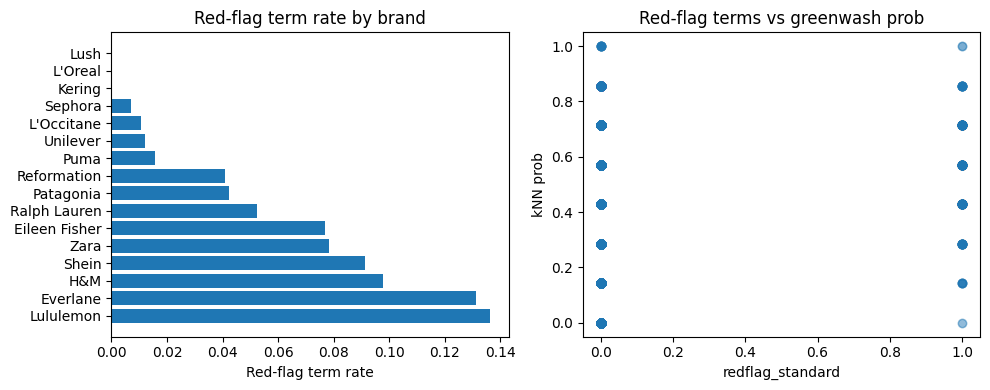

In [15]:
prop_rates = df.groupby('brand').agg(
    n              = ('passage_id', 'count'),
    redflag_rate   = ('redflag_standard', 'mean'),
    mean_knn_prob  = ('knn_prob', 'mean'),
).round(4).reset_index().sort_values('redflag_rate', ascending=False)

print("Red-flag term rate by brand:")
print(prop_rates.to_string(index=False))

# Cross-tabulate: redflag flag vs greenwash probability
print("\nMean kNN prob by redflag_standard:")
print(df.groupby('redflag_standard')['knn_prob'].mean().round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].barh(prop_rates['brand'], prop_rates['redflag_rate'])
axes[0].set(xlabel='Red-flag term rate', title='Red-flag term rate by brand')
axes[1].scatter(df['redflag_standard'], df['knn_prob'], alpha=0.2)
axes[1].set(xlabel='redflag_standard', ylabel='kNN prob', title='Red-flag terms vs greenwash prob')
plt.tight_layout()
plt.show()

In [16]:
# Export red-flag term rate by brand for Datawrapper
redflag_dw = prop_rates[['brand', 'redflag_rate']].copy()
redflag_dw.columns = ['Brand', 'Red Flag Term Rate']
redflag_dw = redflag_dw.sort_values('Red Flag Term Rate', ascending=False).reset_index(drop=True)

redflag_path = RESULTS / 'redflag_rate_by_brand.csv'
redflag_dw.to_csv(redflag_path, index=False)
print(redflag_dw.to_string(index=False))
print(f"\nSaved → {redflag_path}")

        Brand  Red Flag Term Rate
    Lululemon              0.1362
     Everlane              0.1313
          H&M              0.0976
        Shein              0.0912
         Zara              0.0782
Eileen Fisher              0.0769
 Ralph Lauren              0.0523
    Patagonia              0.0424
  Reformation              0.0409
         Puma              0.0158
     Unilever              0.0122
   L'Occitane              0.0108
      Sephora              0.0072
       Kering              0.0000
      L'Oreal              0.0000
         Lush              0.0000

Saved → /Users/mandy.sun/green-claims-nlp/results/redflag_rate_by_brand.csv


## Section 4 — Nearest-neighbour qualitative analysis

For each brand, surfaces the 5 highest-scoring passages alongside their top-3 nearest labeled training neighbors. This is the primary interpretability tool for the kNN model — rather than a black-box score, every prediction is grounded in concrete examples: *"this passage was flagged because it closely resembles these labeled greenwash-risk passages."*

**How to read the output:**
- `kNN prob` = fraction of the k nearest labeled training passages that were labeled greenwash-risk
- `dist` = cosine distance (0 = identical, 1 = orthogonal); lower = more similar
- Nearest neighbor label tells you *why* the model flagged it — if all 3 neighbors are `[greenwash-risk]`, the flag is confident

**Output:** `results/qualitative_examples.md` — use this file to select poster examples in Section 7.

In [8]:
corpus_text_map = {p['passage_id']: p['text'] for p in corpus}
qual_lines = []

for brand in df['brand'].unique():
    brand_df = df[df['brand'] == brand].nlargest(5, 'knn_prob')
    qual_lines.append(f"\n{'='*72}\n## {brand}\n{'='*72}")

    for _, row in brand_df.iterrows():
        text  = corpus_text_map.get(row['passage_id'], '')
        prob  = row['knn_prob']
        nn_ix = row['nn_indices'][:3]
        nn_ds = row['nn_distances'][:3]

        entry = [
            f"\n**Passage {row['passage_id']}** | kNN prob = {prob:.3f} | scope = {row['scope']}",
            f"redflag_standard = {row['redflag_standard']} | vague_language_score = {row['vague_language_score']:.3f}",
            "",
            fill(text[:600], 72),
            "",
            "Top-3 nearest labeled neighbors:",
        ]
        for rank, (idx, dist) in enumerate(zip(nn_ix, nn_ds), 1):
            if idx < len(labeled):
                nb = labeled[idx]
                label_name = {0: 'substantive', 1: 'greenwash-risk', 2: 'ambiguous'}[nb['label']]
                entry.append(f"  {rank}. [{label_name}] dist={dist:.3f} — {nb['text'][:120]}...")
        qual_lines.append('\n'.join(entry))

qual_text = '\n'.join(qual_lines)
qual_path = RESULTS / 'qualitative_examples.md'
with open(qual_path, 'w') as f:
    f.write(qual_text)

print(qual_text[:2000])
print(f"\n... (full text saved to {qual_path})")


## H&M

**Passage 33** | kNN prob = 1.000 | scope = supply_chain
redflag_standard = 1 | vague_language_score = 0.015

OUR VALUE CHAIN Flexibility and efficiency all along the value chain
Through continuous development and a firm commitment, H&M Group’s value
chain reflects our journey towards a more transparent and efficient
business model designed to meet the expectations of today’s conscious
consumer. To give customers the best offering in the right channel at
the right time, we focus on securing a demand-driven and flexible supply
chain that can react quickly to trends and changing customer behaviour.
Reducing emissions in the value chain Reducing our greenhouse gas
emissions in the value chain is a contin

Top-3 nearest labeled neighbors:
  1. [greenwash-risk] dist=0.388 — We can be stewards of the natural world for generations to come and operate an enduring business by embracing practices ...
  2. [greenwash-risk] dist=0.424 — We are committed to minimizing downstream impacts wh

In [ ]:
# Export high-confidence flags (knn_prob >= 0.71, excluding 1.0 duplicates) with neighbor texts
label_name_map = {0: 'substantive', 1: 'greenwash-risk', 2: 'ambiguous'}
corpus_text_map = {p['passage_id']: p['text'] for p in corpus}

# 0.71 = at least 5 of 7 neighbors are greenwash-risk; exclude 1.0 (overlaps with training passages)
top_flags = df[(df['knn_prob'] >= 0.71) & (df['knn_prob'] < 1.0)].copy()

rows = []
for _, row in top_flags.iterrows():
    passage_text = corpus_text_map.get(row['passage_id'], '')
    nn_ix = row['nn_indices'][:3]
    nn_ds = row['nn_distances'][:3]
    for rank, (idx, dist) in enumerate(zip(nn_ix, nn_ds), 1):
        if idx < len(labeled):
            nb = labeled[idx]
            rows.append({
                'passage_id':     row['passage_id'],
                'brand':          row['brand'],
                'scope':          row['scope'],
                'knn_prob':       row['knn_prob'],
                'tfidf_prob':     row['tfidf_prob'],
                'flagged_text':   passage_text[:500],
                'neighbor_rank':  rank,
                'neighbor_label': label_name_map[nb['label']],
                'neighbor_dist':  round(dist, 4),
                'neighbor_brand': nb.get('brand', ''),
                'neighbor_text':  nb['text'][:300],
            })

nn_export = pd.DataFrame(rows)
nn_path = RESULTS / 'top_flags_with_neighbors.csv'
nn_export.to_csv(nn_path, index=False)
print(f"{len(top_flags)} high-confidence passages → {len(nn_export)} rows (3 neighbors each)")
print(f"Saved → {nn_path}")
print(nn_export[['brand', 'passage_id', 'knn_prob', 'neighbor_rank', 'neighbor_label', 'neighbor_dist', 'neighbor_brand']].to_string(index=False))

## Section 5 — Cross-industry feature comparison

Compares the two industries — fashion and clean beauty — across the handcrafted features from Phase 3. This tests whether greenwashing manifests differently across sectors or whether the same linguistic patterns appear in both.

**Features compared:**
- `vague_language_score` — density of hedging/uncertainty words (Loughran-McDonald wordlist)
- `has_specific_numbers` — presence of quantitative targets (year + percentage pattern)
- `redflag_standard` — use of proprietary/unverified sustainability labels
- `readability_grade` — Flesch-Kincaid grade level (higher = more complex)
- `unregulated_beauty_claim` — clean beauty specific terms (`clean`, `non-toxic`, `natural`) that have no regulatory definition

**Expected pattern:** Clean beauty reports may score higher on `unregulated_beauty_claim` by definition, but fashion reports are expected to score higher on `redflag_standard` due to supply-chain certification theatre. Readability differences may reflect different disclosure conventions between industries.

**Output:** `results/feature_comparison.csv`

Industry-level feature comparison:
    industry    n  mean_vague_language  pct_specific_numbers  pct_redflag  pct_unregulated_beauty  mean_readability_grade  mean_knn_prob
clean_beauty 1004               0.0033                0.6683       0.0100                  0.4811                 17.4874         0.3809
     fashion 3481               0.0028                0.6814       0.0661                  0.0000                 16.5298         0.4312

Fashion vague language score by scope:
scope
mixed           0.0025
own_ops         0.0018
supply_chain    0.0031
unclear         0.0027
Name: vague_language_score, dtype: float64

Clean beauty vague language score by scope:
scope
mixed           0.0020
own_ops         0.0028
supply_chain    0.0040
unclear         0.0031
Name: vague_language_score, dtype: float64


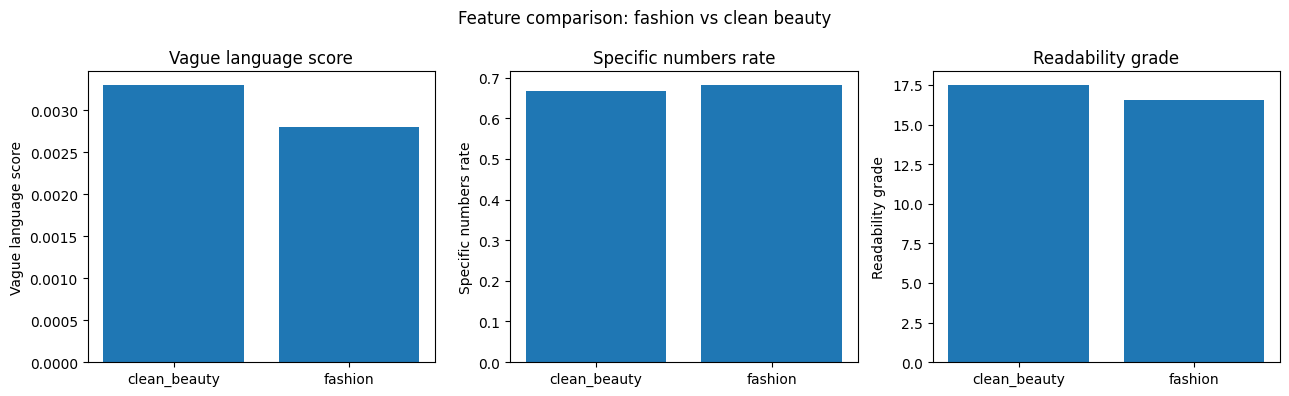

In [9]:
feat_comparison = df.groupby('industry').agg(
    n                        = ('passage_id', 'count'),
    mean_vague_language      = ('vague_language_score', 'mean'),
    pct_specific_numbers     = ('has_specific_numbers', 'mean'),
    pct_redflag              = ('redflag_standard', 'mean'),
    pct_unregulated_beauty   = ('unregulated_beauty_claim', 'mean'),
    mean_readability_grade   = ('readability_grade', 'mean'),
    mean_knn_prob            = ('knn_prob', 'mean'),
).round(4).reset_index()

print("Industry-level feature comparison:")
print(feat_comparison.to_string(index=False))

feat_comparison.to_csv(RESULTS / 'feature_comparison.csv', index=False)

# Refined hypothesis: fashion supply-chain passages show higher vague language
fashion_scope = df[df['industry'] == 'fashion'].groupby('scope')['vague_language_score'].mean()
beauty_scope  = df[df['industry'] == 'clean_beauty'].groupby('scope')['vague_language_score'].mean()

print("\nFashion vague language score by scope:")
print(fashion_scope.round(4))
print("\nClean beauty vague language score by scope:")
print(beauty_scope.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = [('mean_vague_language', 'Vague language score'),
           ('pct_specific_numbers', 'Specific numbers rate'),
           ('mean_readability_grade', 'Readability grade')]
for ax, (col, label) in zip(axes, metrics):
    ax.bar(feat_comparison['industry'], feat_comparison[col])
    ax.set(title=label, ylabel=label)
plt.suptitle('Feature comparison: fashion vs clean beauty')
plt.tight_layout()
plt.show()

## Section 6 — t-SNE Embedding Visualisation (poster figure)

Projects the 384-dimensional sentence embeddings down to 2D using t-SNE. This visualises what the kNN classifier actually sees: passages that cluster together are semantically similar, and the model votes based on which labelled neighbours are closest.

**Reading the plot:**
- Large coloured points = manually labelled training passages (ground truth)
- Small grey points = unlabelled corpus passages
- Black-outlined points = top-flagged corpus passages (kNN prob > 0.8), annotated with brand name

Running t-SNE on 4,577 points… (may take ~1–2 min)
Done.


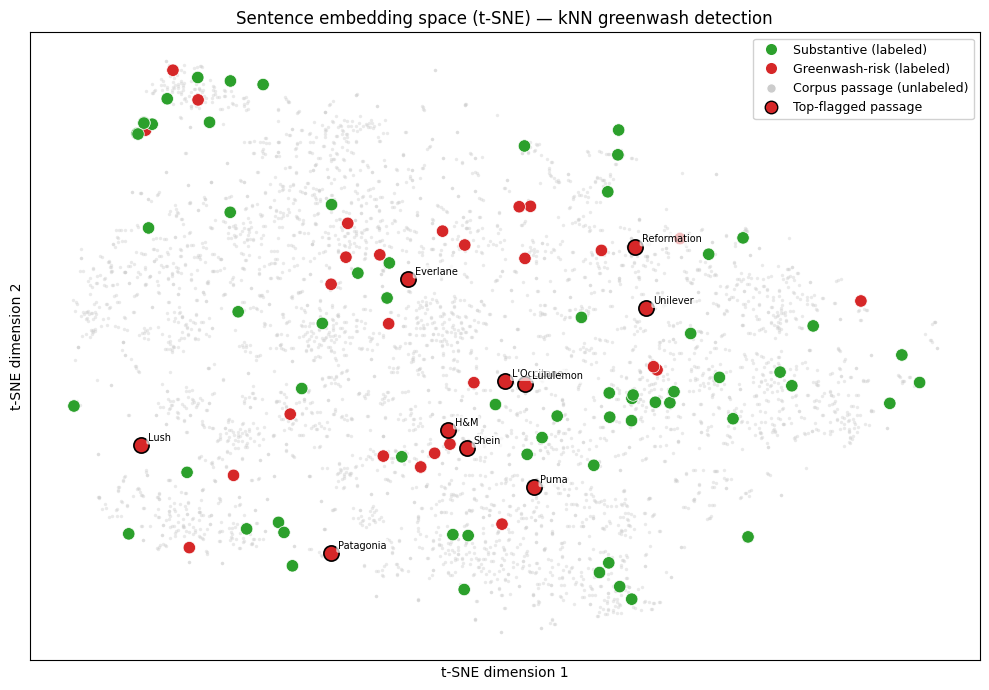

Saved → /Users/mandy.sun/green-claims-nlp/results/tsne_embeddings.png


In [10]:
from sklearn.manifold import TSNE

# Load embeddings
X_corpus_emb = np.load(FEAT_DIR / 'corpus_embeddings.npy')
X_train_emb  = np.load(FEAT_DIR / 'labeled_embeddings.npy')

with open(ROOT / 'data' / 'labeled' / 'labeled_passages.jsonl') as f:
    labeled_meta = [json.loads(l) for l in f]
train_labels_list = [p['label'] for p in labeled_meta]

# Build passage_id → row position in corpus array
corpus_pos = {p['passage_id']: i for i, p in enumerate(corpus)}

# Stack corpus and training embeddings so they share the same 2D space
n_corpus = len(X_corpus_emb)
all_emb  = np.vstack([X_corpus_emb, X_train_emb])

print(f"Running t-SNE on {len(all_emb):,} points… (may take ~1–2 min)")
tsne = TSNE(n_components=2, metric='cosine', perplexity=40,
            max_iter=1000, random_state=42, init='random')
all_2d    = tsne.fit_transform(all_emb)
corpus_2d = all_2d[:n_corpus]
train_2d  = all_2d[n_corpus:]
print("Done.")

# Top-flagged passages for annotation (one per brand, highest knn_prob)
top_flagged = (
    df[df['knn_prob'] > 0.8]
    .sort_values('knn_prob', ascending=False)
    .drop_duplicates('brand')
    .head(10)
)
flagged_positions = top_flagged['passage_id'].map(corpus_pos).dropna().astype(int).tolist()
flagged_coords    = corpus_2d[flagged_positions]
flagged_brands    = top_flagged.loc[
    top_flagged['passage_id'].isin(corpus_pos), 'brand'
].tolist()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(corpus_2d[:, 0], corpus_2d[:, 1],
           s=6, c='#cccccc', alpha=0.4, linewidths=0, zorder=1)

colors_train = ['#2ca02c' if l == 0 else '#d62728' for l in train_labels_list]
ax.scatter(train_2d[:, 0], train_2d[:, 1],
           s=80, c=colors_train, edgecolors='white', linewidths=0.5, zorder=3)

ax.scatter(flagged_coords[:, 0], flagged_coords[:, 1],
           s=120, c='#d62728', edgecolors='black', linewidths=1.2, zorder=4)
for (x, y), brand in zip(flagged_coords, flagged_brands):
    ax.annotate(brand, (x, y), fontsize=7, xytext=(5, 3),
                textcoords='offset points', zorder=5,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ca02c',
           markersize=9, label='Substantive (labeled)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728',
           markersize=9, label='Greenwash-risk (labeled)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#cccccc',
           markersize=7, label='Corpus passage (unlabeled)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728',
           markeredgecolor='black', markersize=9, label='Top-flagged passage'),
]
ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9, fontsize=9)
ax.set(title='Sentence embedding space (t-SNE) — kNN greenwash detection',
       xlabel='t-SNE dimension 1', ylabel='t-SNE dimension 2')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(RESULTS / 'tsne_embeddings.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {RESULTS / 'tsne_embeddings.png'}")

## Section 6b — t-SNE on Labeled Passages Only

Running t-SNE on all 4,485 corpus passages compresses 92 labeled points into a crowded space dominated by unlabeled noise. This version runs t-SNE on just the 92 training passages so the class structure — if it exists in the embedding space — has room to emerge.

Lower perplexity (15) is used because the dataset is small; high perplexity on a small set collapses everything into one blob.

Running t-SNE on 92 labeled passages (perplexity=15)…
Done.


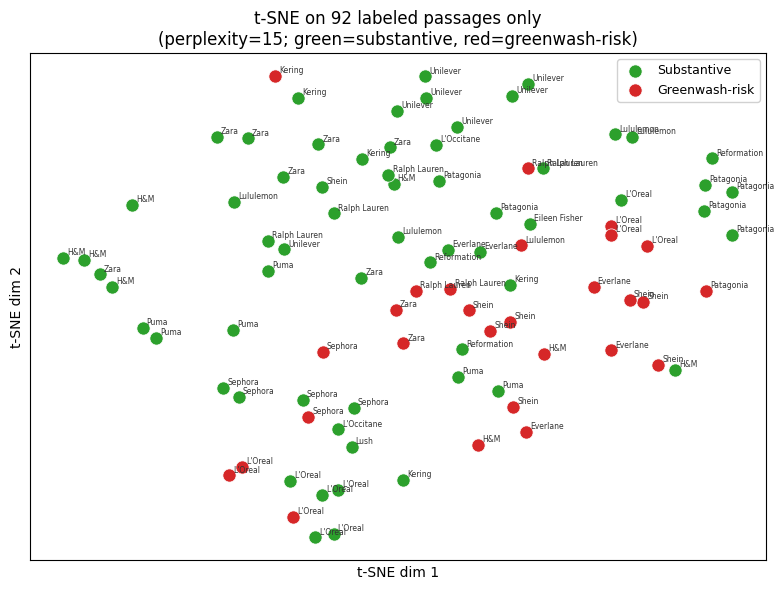

Saved → /Users/mandy.sun/green-claims-nlp/results/tsne_labeled_only.png


In [11]:
from sklearn.manifold import TSNE

# Use the pre-computed labeled embeddings (92 training passages)
X_train_emb = np.load(FEAT_DIR / 'labeled_embeddings.npy')

with open(ROOT / 'data' / 'labeled' / 'labeled_passages.jsonl') as f:
    labeled_meta = [json.loads(l) for l in f]

train_labels_list = [p['label'] for p in labeled_meta]
train_brands_list = [p['brand'] for p in labeled_meta]

print(f"Running t-SNE on {len(X_train_emb)} labeled passages (perplexity=15)…")
tsne_small = TSNE(n_components=2, metric='cosine', perplexity=15,
                  max_iter=1000, random_state=42, init='random')
train_2d_small = tsne_small.fit_transform(X_train_emb)
print("Done.")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

color_map = {0: '#2ca02c', 1: '#d62728'}  # green=substantive, red=greenwash-risk
label_name_map = {0: 'Substantive', 1: 'Greenwash-risk'}

for label_val, label_name in label_name_map.items():
    mask = [l == label_val for l in train_labels_list]
    xs = train_2d_small[mask, 0]
    ys = train_2d_small[mask, 1]
    ax.scatter(xs, ys, s=90, c=color_map[label_val],
               edgecolors='white', linewidths=0.5,
               label=label_name, zorder=3)

# Annotate each point with its brand (small font, slightly offset)
for i, (x, y) in enumerate(train_2d_small):
    ax.annotate(train_brands_list[i], (x, y), fontsize=5.5,
                xytext=(3, 2), textcoords='offset points',
                color='#333333', zorder=4)

ax.legend(loc='upper right', framealpha=0.9, fontsize=9)
ax.set(title='t-SNE on 92 labeled passages only\n(perplexity=15; green=substantive, red=greenwash-risk)',
       xlabel='t-SNE dim 1', ylabel='t-SNE dim 2')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(RESULTS / 'tsne_labeled_only.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {RESULTS / 'tsne_labeled_only.png'}")

## Section 6c — Handcrafted Feature Scatter (Labeled Passages)

The t-SNE above shows the semantic embedding space. This scatter shows the **handcrafted feature space** — the two most interpretable dimensions: vague language density vs. presence of specific quantitative targets.

The key prediction: greenwash-risk passages should cluster in the **top-left** (high vagueness, no specific numbers) while substantive passages cluster in the **bottom-right** (low vagueness, has specific numbers).

Because `labeled_passages.jsonl` stores only `annotation_id` (not `passage_id`), the features are computed inline from the raw text using the same logic as Phase 3 — a lightweight regex + wordlist approach that doesn't require loading the full `features.parquet`.

Label distribution:
label
0    64
1    28

Mean vague score:  label 0 = 0.0088 | label 1 = 0.0168
Specific numbers:  label 0 = 0.0938 | label 1 = 0.1071


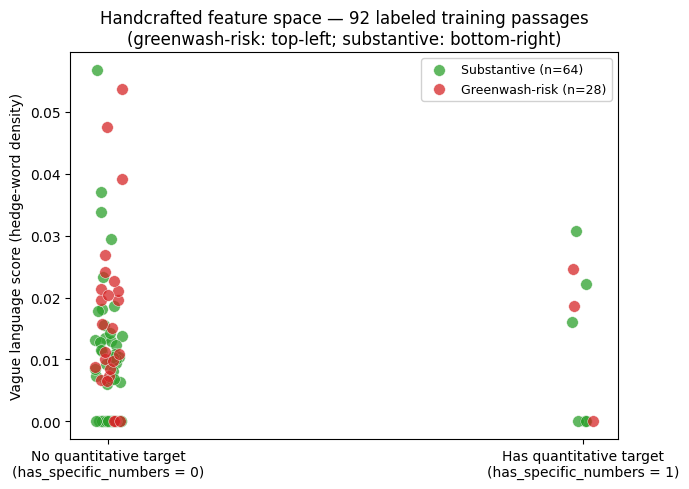

Saved → /Users/mandy.sun/green-claims-nlp/results/feature_scatter_labeled.png


In [12]:
import re

# ── Lightweight feature computation (mirrors Phase 3 logic) ──────────────────
HEDGE_WORDS = {
    'aim', 'aims', 'aimed', 'aiming',
    'commit', 'commits', 'committed', 'committing', 'commitment',
    'strive', 'strives', 'striving', 'aspire', 'aspires', 'aspiring',
    'endeavor', 'endeavour', 'endeavors', 'endeavours',
    'target', 'targets', 'targeting',
    'working', 'towards', 'toward',
    'journey', 'progress', 'plan', 'plans', 'planned', 'planning',
    'seek', 'seeks', 'seeking', 'hope', 'hopes', 'hoping',
    'intend', 'intends', 'intending', 'intention',
    'try', 'tries', 'trying', 'attempt', 'attempts',
    'explore', 'exploring', 'consider', 'considering',
    'promote', 'promoting', 'support', 'supporting', 'encourage',
    'continue', 'continues', 'continuing',
}

# Year + percentage pattern (e.g. "by 2030, reduce by 50%")
_YEAR_PCT = re.compile(
    r'(?:20[2-4]\d[^.]{0,60}\d+\s*%|\d+\s*%[^.]{0,60}20[2-4]\d)'
)

def quick_vague(text: str) -> float:
    """Hedge-word density: count / total tokens."""
    tokens = re.findall(r'[a-z]+', text.lower())
    if not tokens:
        return 0.0
    hedge_count = sum(1 for t in tokens if t in HEDGE_WORDS)
    return round(hedge_count / len(tokens), 4)

def quick_specific(text: str) -> int:
    """1 if text contains a year+percentage quantitative target, else 0."""
    return int(bool(_YEAR_PCT.search(text)))

# ── Apply to labeled passages ─────────────────────────────────────────────────
for p in labeled_meta:
    p['vague_score']   = quick_vague(p['text'])
    p['has_specific']  = quick_specific(p['text'])

lab_df = pd.DataFrame(labeled_meta)
print(f"Label distribution:\n{lab_df['label'].value_counts().to_string()}")
print(f"\nMean vague score:  label 0 = {lab_df[lab_df['label']==0]['vague_score'].mean():.4f} | "
      f"label 1 = {lab_df[lab_df['label']==1]['vague_score'].mean():.4f}")
print(f"Specific numbers:  label 0 = {lab_df[lab_df['label']==0]['has_specific'].mean():.4f} | "
      f"label 1 = {lab_df[lab_df['label']==1]['has_specific'].mean():.4f}")

# ── Scatter plot ──────────────────────────────────────────────────────────────
rng = np.random.default_rng(99)

fig, ax = plt.subplots(figsize=(7, 5))

for label_val, label_name, color in [
    (0, 'Substantive',    '#2ca02c'),
    (1, 'Greenwash-risk', '#d62728'),
]:
    subset = lab_df[lab_df['label'] == label_val]
    # Jitter the binary x-axis so points don't all overlap
    jitter = rng.uniform(-0.03, 0.03, size=len(subset))
    ax.scatter(
        subset['has_specific'] + jitter,
        subset['vague_score'],
        s=70, c=color, alpha=0.75,
        edgecolors='white', linewidths=0.4,
        label=f'{label_name} (n={len(subset)})',
        zorder=3,
    )

ax.set_xticks([0, 1])
ax.set_xticklabels(['No quantitative target\n(has_specific_numbers = 0)',
                    'Has quantitative target\n(has_specific_numbers = 1)'])
ax.set(
    ylabel='Vague language score (hedge-word density)',
    title='Handcrafted feature space — 92 labeled training passages\n'
          '(greenwash-risk: top-left; substantive: bottom-right)',
)
ax.legend(framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS / 'feature_scatter_labeled.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {RESULTS / 'feature_scatter_labeled.png'}")

## Section 7 — Poster Example Passages

Curates contrasting passage pairs for the poster — the most intuitive way to communicate what the model detects to a non-expert audience.

**Selection criteria:**
- **Greenwash-risk candidates:** both Track A (kNN prob ≥ 0.85) and Track B (TF-IDF prob ≥ 0.6) agree, and passage is under 800 characters so it's readable on a poster
- **Substantive candidates:** both tracks agree the passage is low-risk, it contains specific numbers (`has_specific_numbers = 1`), and is under 800 characters

Requiring **both tracks to agree** ensures the examples shown are high-confidence predictions, not borderline cases. The printed output shows 5 candidates per class — pick the clearest contrast pair for the poster, ideally from different brands.

In [13]:
corpus_text_map = {p['passage_id']: p['text'] for p in corpus}

# High-confidence greenwash-risk: both tracks agree, short enough to read on a poster
greenwash_candidates = df[
    (df['knn_prob'] >= 0.85) &
    (df['tfidf_prob'] >= 0.6) &
    (df['text_length_chars'] < 800)
].copy()
greenwash_candidates['text'] = greenwash_candidates['passage_id'].map(corpus_text_map)
greenwash_candidates = greenwash_candidates.dropna(subset=['text'])

# High-confidence substantive: both tracks agree low, has specific numbers
substantive_candidates = df[
    (df['knn_prob'] <= 0.15) &
    (df['tfidf_prob'] <= 0.3) &
    (df['has_specific_numbers'] == 1) &
    (df['text_length_chars'] < 800)
].copy()
substantive_candidates['text'] = substantive_candidates['passage_id'].map(corpus_text_map)
substantive_candidates = substantive_candidates.dropna(subset=['text'])

print(f"Greenwash-risk candidates: {len(greenwash_candidates)}")
print(f"Substantive candidates:    {len(substantive_candidates)}")

# Show top 5 of each — pick from these for the poster
print("\n" + "="*72)
print("TOP GREENWASH-RISK PASSAGES (both tracks agree, short)")
print("="*72)
for _, row in greenwash_candidates.nlargest(5, 'knn_prob').iterrows():
    print(f"\n[{row['brand']}] kNN={row['knn_prob']:.2f} TF-IDF={row['tfidf_prob']:.2f}")
    print(fill(row['text'][:400], 72))

print("\n" + "="*72)
print("TOP SUBSTANTIVE PASSAGES (both tracks agree, has numbers)")
print("="*72)
for _, row in substantive_candidates.nlargest(5, 'knn_prob', keep='last').iterrows():
    print(f"\n[{row['brand']}] kNN={row['knn_prob']:.2f} TF-IDF={row['tfidf_prob']:.2f}")
    print(fill(row['text'][:400], 72))

Greenwash-risk candidates: 2
Substantive candidates:    0

TOP GREENWASH-RISK PASSAGES (both tracks agree, short)

[Shein] kNN=0.86 TF-IDF=0.64
Product Manufacturing Goal On-demand: Avoid overproduction through small
batch on-demand business model. Drive positive change in fashion and
beyond by rapidly testing and scaling sustainable innovations and
impact. - Innovation: Adopt and scale innovation in garment production
to reduce waste. Goal Optimise efficiency to conserve resources;
leverage technology and creativity to minimise waste. In

[L'Oreal] kNN=0.86 TF-IDF=0.69
- (6) Includes financial lease debt. (7) As of 31 December 2025. - (10)
Based on the share price as of 31 December 2025. Social and
environmental highlights 2025 progress towards our goals From addressing
the impacts of climate change and safeguarding natural resources, to
championing circularity and building community resilience, L’Oréal’s
actions are anchored in the latest environmental science

TOP SUBSTANTIVE PASSAG